# 멋진 챗봇 만들기

## 라이브러리 설치 및 import

In [64]:
# 1. 외부 라이브러리 및 시스템 패키지 설치 -> 외부에서 실행
# !apt-get install -y mariadb-server
# !pip install konlpy mecab-python3 sentencepiece gensim nltk
# !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)
# !pip install tensorflow

# 2. 라이브러리 임포트 (중복 제거 및 그룹화)
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import nltk
import gensim
import sentencepiece as spm
import tensorflow as tf
import torch.nn as nn
import torch.nn.functional as F

from tqdm.notebook import tqdm
from konlpy.tag import Mecab
from gensim.models import Word2Vec, KeyedVectors
from sklearn.model_selection import train_test_split

# 3. 버전 확인
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"NLTK: {nltk.__version__}")
print(f"Gensim: {gensim.__version__}")

NumPy: 2.2.6
Pandas: 2.3.0
PyTorch: 2.7.1+cu118
TensorFlow: 2.20.0
NLTK: 3.9.3
Gensim: 4.4.0


## 데이터 다운로드

In [65]:
url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
df = pd.read_csv(url)
print(df.head())

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


In [66]:
# [설정] 모든 하이퍼파라미터를 한곳에서 관리합니다.
CFG = {
    "PRE_MAX_LEN": 50,
    "DEVICE": (lambda: torch.device('cuda') if torch.cuda.is_available() 
        else torch.device('mps') if torch.backends.mps.is_available() 
        else torch.device('cpu')
    )(),
    "VOCAB_SIZE": 3500,
    "AUG_DATA": "project_transformer/data/ko.kv"  # "data/ko.kv"
}

# [Mecab 선언]
if(CFG["DEVICE"].type == 'mps'):
    MOCAB_PATH = '/opt/homebrew/lib/mecab/dic/mecab-ko-dic'
    os.environ['MECABRC'] = MOCAB_PATH
    mecab = Mecab(MOCAB_PATH)
else:
    mecab = Mecab()

print(f"사용 장치: {CFG['DEVICE']}")

사용 장치: cuda


## 데이터 정제 및 분리
preprocess_sentence() 함수를 구현하기<br>
영문자의 경우, 모두 소문자로 변환한다. 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거.

In [67]:
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z0-9ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence) # 영어,숫자,한글,특수무자 제외하고 제거
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    
    return sentence

In [68]:
# 3. 데이터 분할 (8:1:1)
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 9458, Val: 1182, Test: 1183


In [69]:
# 3. 분할된 각 데이터셋에 정제 함수를 적용하여 리스트로 만듭니다.
train_questions = [preprocess_sentence(q) for q in train_data['Q']]
train_answers = [preprocess_sentence(a) for a in train_data['A']]

val_questions = [preprocess_sentence(q) for q in val_data['Q']]
val_answers = [preprocess_sentence(a) for a in val_data['A']]

test_questions = [preprocess_sentence(q) for q in test_data['Q']]
test_answers = [preprocess_sentence(a) for a in test_data['A']]

print(f"✅ 데이터 분할 및 정제 완료!")
print(f"Train: {len(train_questions)}, Val: {len(val_questions)}, Test: {len(test_questions)}")

✅ 데이터 분할 및 정제 완료!
Train: 9458, Val: 1182, Test: 1183


**데이터 분리 → 토큰화하기**<br>
토큰화를 먼저 하면, 전체 데이터를 토큰화하면서 Test 세트에만 있는 단어나 통계적 정보가 Train 세트의 단어 사전에 포함되어 버린다.<br>
**(정석대로라면)** 모델이 공부하기도 전에 시험 문제를 미리 엿보는 꼴이 되어, 실제 실력보다 점수가 높게 나오는 '가짜 성능'이 발생한다고 한다.

## 토큰화
이 섹션에서는 한국어 형태소 분석기인 Mecab을 사용하여 데이터를 토큰화하고, 학습에 적합한 형태로 정제하여 최종 코퍼스를 구축한다.

In [70]:
def build_corpus(src_data, tgt_data, tokenize_func, max_len=50):
    que_corpus = []
    ans_corpus = []
    
    seen_src = set()
    seen_tgt = set()
    for src, tgt in zip(src_data, tgt_data):
        # 1) preprocess_sentence() 함수로 정제
        pre_src = preprocess_sentence(src)
        pre_tgt = preprocess_sentence(tgt)
        
        # 2) 전달받은 토크나이즈 함수(mecab.morphs)로 토큰화
        src_tokens = tokenize_func(pre_src)
        tgt_tokens = tokenize_func(pre_tgt)
        
        # 3) 길이 제한 확인
        if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
            # 4) 중복 제거 (소는 소스대로, 타겟은 타겟대로 독립 검사)
            # 쌍의 관계를 유지하기 위해 한쪽이라도 중복이면 해당 쌍 전체를 제외합니다.
            if pre_src not in seen_src and pre_tgt not in seen_tgt:
                seen_src.add(pre_src)
                seen_tgt.add(pre_tgt)
                
                que_corpus.append(src_tokens)
                ans_corpus.append(tgt_tokens)
                
    return que_corpus, ans_corpus
    
# 1차 토큰화 → 데이터 정제(중복 제거, 토큰화, 길이 제한)
# def build_corpus(src_sentences, tgt_sentences, tokenizer, max_len=50):
#     que_corpus = []
#     ans_corpus = []
    
#     # 중복 제거를 위한 셋(set) 활용
#     seen = set()
    
#     for src, tgt in zip(src_sentences, tgt_sentences):
#         # 1. 토큰화 (mecab)
#         src_tokens = tokenizer(src)
#         tgt_tokens = tokenizer(tgt)
        
#         # 2. 길이 제한 확인
#         if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
#             pair = (tuple(src_tokens), tuple(tgt_tokens))
            
#             # 3. 중복 확인
#             if pair not in seen:
#                 seen.add(pair)
#                 que_corpus.append(list(src_tokens))
#                 ans_corpus.append(list(tgt_tokens))
                
#     return que_corpus, ans_corpus

# print("✅ build_corpus 함수 정의 완료")

- 아무리 train set 비중을 늘려서 단어개수가 많아진다고 해도, 중복 제거를 하고 나면 남은 단어가 별로 없을 수 있다.<br>
→ **vocab_size를 3500으로 설정함**<br><br>
- 모든 데이터를 한꺼번에 넣고 진행하던 것 → **train set만 토큰화(단어장용), 증강 진행**<br>
- 참고 : 인코딩을 말하는 토큰화는 Train/Val/Test 모두에 해야 한다.<br>

## 증강

In [71]:
# 유사어 나오는지 체크
word2vec = KeyedVectors.load(CFG["AUG_DATA"])

print("테스트 유사어:", word2vec.most_similar("사랑", topn=3))

테스트 유사어: [('슬픔', 0.7216663360595703), ('행복', 0.6759076714515686), ('절망', 0.6468985676765442)]


In [72]:
import random
from tqdm.auto import tqdm

# 1. 단어 치환 함수 정의
def lexical_sub(sentence, word2vec_model):
    """
    토큰화된 리스트(sentence)를 입력받아 랜덤하게 한 단어를 유사어로 교체합니다.
    """
    res = []
    toks = sentence

    try:
        # 문장에서 랜덤하게 단어 하나 선택
        _from = random.choice(toks)
        # 선택한 단어와 유사한 단어 TOP 10 중 하나 무작위 선택
        candidates = word2vec_model.wv.most_similar(_from, topn=10)
        _to = random.choice(candidates)[0]
        
        # 선택된 단어 치환
        res = [tok if tok != _from else _to for tok in toks]
    except:
        # 사전에 단어가 없거나 에러 발생 시 원본 반환
        res = toks

    return res

# 2. 질문/답변 추출 및 초기 코퍼스 생성
train_questions = train_data['Q'].tolist()
train_answers = train_data['A'].tolist()

# 1차 토큰화: 형태소 분석 (Mecab)
# build_corpus를 통해 깨끗한 원본 코퍼스를 먼저 생성합니다.
que_corpus, ans_corpus = build_corpus(train_questions, train_answers, mecab.morphs, max_len=50)

# 3. 데이터 증강 진행 (기존 1, 2, 3, 5번 코드 통합)
added_que_corpus = []
added_ans_corpus = []
original_len = len(que_corpus)

print(f"원본 데이터 개수: {original_len}")

for i in tqdm(range(original_len), desc="데이터 증강 중"):
    # (A) 질문 증강 + 원본 답변 (1배수 추가)
    aug_q = lexical_sub(que_corpus[i], word2vec) # 변수명이 word2vec인지 확인하세요
    added_que_corpus.append(aug_q)
    added_ans_corpus.append(ans_corpus[i])
    
    # (B) 원본 질문 + 답변 증강 (또 다른 1배수 추가)
    aug_a = lexical_sub(ans_corpus[i], word2vec)
    added_que_corpus.append(que_corpus[i])
    added_ans_corpus.append(aug_a)

# 4. 원본 코퍼스에 증강분 합쳐서 최종 3배수 만들기
que_corpus += added_que_corpus
ans_corpus += added_ans_corpus

print(f"✅ 데이터 증강 및 통합 완료!")
print(f"최종 코퍼스 크기: {len(que_corpus)} (원본의 3배)")

# 데이터 쌍 일치 확인
assert len(que_corpus) == len(ans_corpus), "질문과 답변의 개수가 일치하지 않습니다!"

원본 데이터 개수: 6688


데이터 증강 중:   0%|          | 0/6688 [00:00<?, ?it/s]

✅ 데이터 증강 및 통합 완료!
최종 코퍼스 크기: 20064 (원본의 3배)


## 데이터 벡터화

In [73]:
import sentencepiece as spm

def generate_tokenizer(corpus, vocab_size, lang):
    """
    SentencePiece를 학습하고 모델을 불러오는 함수입니다.
    기존 코드의 흐름을 방해하지 않도록 최소한의 로직만 담았습니다.
    """
    temp_file = f'chatbot_{lang}.txt'
    
    # 1. 학습을 위한 임시 텍스트 파일 생성
    with open(temp_file, 'w', encoding='utf-8') as f:
        for tokens in corpus:
            f.write(" ".join(tokens) + '\n')
    
    # 2. SentencePiece 학습
    spm.SentencePieceTrainer.train(
        input=temp_file, 
        model_prefix=lang, 
        vocab_size=vocab_size,
        model_type='bpe', # 가장 범용적인 bpe 타입
        pad_id=0, bos_id=1, eos_id=2, unk_id=3
    )
    
    # 3. 학습된 모델 로드
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.load(f'{lang}.model')
    
    return tokenizer

print("✅ generate_tokenizer 함수 정의 완료! 이제 아래 셀을 실행하세요.")

✅ generate_tokenizer 함수 정의 완료! 이제 아래 셀을 실행하세요.


In [74]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# [1] 토크나이저 학습 및 설정
# 훈련 데이터(증강 포함)로만 학습하여 데이터 누수를 차단합니다.
# 2차 토큰화: 서브워드 인코딩 (SentencePiece)
tokenizer = generate_tokenizer(que_corpus + ans_corpus, CFG["VOCAB_SIZE"], 'kor')
tokenizer.set_encode_extra_options("bos:eos") 

# [2] 인코딩 함수 정의 (중복 특수 토큰 버그 수정 버전)
def make_corpus(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        # 형태소 리스트를 공백으로 합쳐 하나의 문장으로 변환해야 <s> </s>가 앞뒤에 한 번씩만 붙습니다.
        full_sentence = " ".join(sentence)
        tokens = tokenizer.encode_as_ids(full_sentence)
        corpus.append(tokens)
    return corpus

# [3] 모든 데이터셋 인코딩 진행
print("훈련 데이터 변환 중...")
enc_train = make_corpus(que_corpus, tokenizer)
dec_train = make_corpus(ans_corpus, tokenizer)

print("검증 데이터 변환 중...")
# 검증 데이터는 build_corpus를 통해 정제한 후 인코딩합니다.
val_que_raw, val_ans_raw = build_corpus(val_data['Q'].tolist(), val_data['A'].tolist(), mecab.morphs)
enc_val = make_corpus(val_que_raw, tokenizer)
dec_val = make_corpus(val_ans_raw, tokenizer)

print("테스트 데이터 변환 중...")
# 테스트 데이터도 동일하게 처리합니다.
test_que_raw, test_ans_raw = build_corpus(test_data['Q'].tolist(), test_data['A'].tolist(), mecab.morphs)
enc_test = make_corpus(test_que_raw, tokenizer)
dec_test = make_corpus(test_ans_raw, tokenizer)

print(f"\n✅ 모든 변환 완료!")
print(f"결과 확인 - Train: {len(enc_train)}, Val: {len(enc_val)}, Test: {len(enc_test)}")

# 샘플 출력으로 버그 수정 확인
print(f"\n[샘플 확인] SRC ids: {enc_train[0]}") 
# 결과 숫자가 1로 시작해서 2로 끝나면 성공입니다.

훈련 데이터 변환 중...


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_kor.txt
  input_format: 
  model_prefix: kor
  model_type: BPE
  vocab_size: 3500
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential

  0%|          | 0/20064 [00:00<?, ?it/s]

  0%|          | 0/20064 [00:00<?, ?it/s]

검증 데이터 변환 중...


...

  0%|          | 0/1128 [00:00<?, ?it/s]

테스트 데이터 변환 중...


  0%|          | 0/1109 [00:00<?, ?it/s]

  0%|          | 0/1109 [00:00<?, ?it/s]


✅ 모든 변환 완료!
결과 확인 - Train: 20064, Val: 1128, Test: 1109

[샘플 확인] SRC ids: [1, 772, 1373, 12, 2]


In [75]:
# 확인하고 싶은 샘플의 인덱스 (0번부터 원하는 번호까지)
sample_indices = [0, 10, 100] 

print("=== 토큰화 상세 확인 ===\n")

for idx in sample_indices:
    # 1. 원본 형태소 (Mecab 결과)
    original_morphemes = que_corpus[idx]
    
    # 2. 인코딩을 위해 합쳐진 문장
    full_sentence = " ".join(original_morphemes)
    
    # 3. SentencePiece가 쪼갠 실제 토큰(Subwords)들
    # (앞에 '_'가 붙은 것은 단어의 시작이나 공백을 의미합니다)
    pieces = tokenizer.encode_as_pieces(full_sentence)
    
    # 4. 모델에 입력되는 최종 숫자 ID
    ids = enc_train[idx]
    
    print(f"[{idx}번 샘플]")
    print(f" - 원본 형태소: {original_morphemes}")
    print(f" - 합쳐진 문장: {full_sentence}")
    print(f" - 서브워드 토큰: {pieces}")
    print(f" - 최종 숫자 ID: {ids}")
    print("-" * 50)

# 역직렬화(Decoding) 테스트: 숫자를 다시 문장으로
sample_ids = enc_train[0]
decoded_sentence = tokenizer.decode_ids(sample_ids)
print(f"\n[디코딩 테스트] 0번 ID들을 문장으로 복원: {decoded_sentence}")

=== 토큰화 상세 확인 ===

[0번 샘플]
 - 원본 형태소: ['엄청', '로맨틱', '해']
 - 합쳐진 문장: 엄청 로맨틱 해
 - 서브워드 토큰: ['<s>', '▁엄청', '▁로맨틱', '▁해', '</s>']
 - 최종 숫자 ID: [1, 772, 1373, 12, 2]
--------------------------------------------------
[10번 샘플]
 - 원본 형태소: ['가족', '들', '이랑', '어디', '가', '지', '?']
 - 합쳐진 문장: 가족 들 이랑 어디 가 지 ?
 - 서브워드 토큰: ['<s>', '▁가족', '▁들', '▁이랑', '▁어디', '▁가', '▁지', '▁?', '</s>']
 - 최종 숫자 ID: [1, 831, 87, 236, 483, 11, 14, 26, 2]
--------------------------------------------------
[100번 샘플]
 - 원본 형태소: ['연애', '감흥', '이', '점점', '사라져']
 - 합쳐진 문장: 연애 감흥 이 점점 사라져
 - 서브워드 토큰: ['<s>', '▁연애', '▁감', '흥', '▁이', '▁점점', '▁사라', '져', '</s>']
 - 최종 숫자 ID: [1, 147, 162, 3193, 5, 928, 1331, 2679, 2]
--------------------------------------------------

[디코딩 테스트] 0번 ID들을 문장으로 복원: 엄청 로맨틱 해


<br>**형태소와 서브워드 사이에 문장 합치는 이유 : (# 2. 인코딩을 위해 합쳐진 문장 부분)** <br>
1. 1차 토큰화 결과는 ['엄청', '로맨틱', '해']라는 리스트 형태. <Br>
2. 하지만 2차 토크나이저인 SentencePiece는 "문자열(String)"을 입력으로 받아야 한다.<br>
3. 그래서 리스트의 요소들을 공백( )으로 합쳐서 "엄청 로맨틱 해"라는 하나의 문장으로 다시 만든 뒤 SentencePiece에 넣어줌.

**특수 토큰 위치 (1로 시작해서 2로 끝남)** <br>
SRC ids가 **1**로 시작하고 **2**로 끝나는 것이 가장 중요하다.<br>

1 (`<s>`): 문장의 시작을 알리는 토큰<br>
2 (`</s>`): 문장의 끝을 알리는 토큰<br>

→ 중간에 다른 1이나 2가 섞이지 않고 앞뒤에 딱 한 번씩만 붙었다는 것은, make_corpus 함수 내에서 " ".join(sentence) 로직이 의도대로 정확히 작동했다는 뜻이다.<br>

**너무 잦은 `<s>, </s>` 문제 해결**
- 중복 토큰 해결: make_corpus에서 " ".join(sentence)를 사용하여 문장 앞뒤에만 <s>, </s>가 붙도록 수정.
- 호환성 확보: 이 수정을 통해 데이터가 2차원이 되어 Node_12의 pad_sequences_custom 함수를 에러 없이 바로 쓸 수 있게 됨.
- 성능 향상: 불필요한 특수 토큰 노이즈가 제거되어 모델이 문장의 시작과 끝을 훨씬 더 정확하게 학습하게 됩니다.

## 패딩 및 텐서 변환

In [76]:
# 1. 모든 데이터셋 패딩 (최대 길이 CFG["PRE_MAX_LEN"]인 50에 맞춤)
# 인코딩된 리스트를 고정된 길이의 넘파이 배열로 변환합니다.
enc_train_padded = pad_sequences(enc_train, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)
dec_train_padded = pad_sequences(dec_train, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)

enc_val_padded = pad_sequences(enc_val, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)
dec_val_padded = pad_sequences(dec_val, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)

enc_test_padded = pad_sequences(enc_test, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)
dec_test_padded = pad_sequences(dec_test, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)

# 2. PyTorch 텐서(Tensor)로 변환 및 장치(GPU/CPU) 할당
# 이 과정에서 질문자님이 발생했던 NameError의 원인인 'train_inputs' 등이 정의됩니다.
train_inputs = torch.LongTensor(enc_train_padded).to(CFG["DEVICE"])
train_outputs = torch.LongTensor(dec_train_padded).to(CFG["DEVICE"])

val_inputs = torch.LongTensor(enc_val_padded).to(CFG["DEVICE"])
val_outputs = torch.LongTensor(dec_val_padded).to(CFG["DEVICE"])

test_inputs = torch.LongTensor(enc_test_padded).to(CFG["DEVICE"])
test_outputs = torch.LongTensor(dec_test_padded).to(CFG["DEVICE"])

print("✅ 패딩 및 텐서 변환 완료!")
print(f"학습 데이터 형태  : {train_inputs.shape}")
print(f"검증 데이터 형태  : {val_inputs.shape}")
print(f"테스트 데이터 형태: {test_inputs.shape}")

✅ 패딩 및 텐서 변환 완료!
학습 데이터 형태  : torch.Size([20064, 50])
검증 데이터 형태  : torch.Size([1128, 50])
테스트 데이터 형태: torch.Size([1109, 50])


## 하이퍼파라미터 설정 및 트랜스포머 핵심 함수 (Masking & Attention)

In [77]:
from torch.utils.data import TensorDataset, DataLoader

# 1. 하이퍼파라미터 설정 (Node_12 기준)
D_MODEL = 512
N_LAYERS = 2
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.3
device = CFG["DEVICE"]

# 2. 데이터 로더 구성
train_dataset = TensorDataset(train_inputs, train_outputs)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = TensorDataset(val_inputs, val_outputs)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 3. Positional Encoding (고정된 사인/코사인 함수 방식)
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

# 4. 마스킹 생성 함수 (패딩 마스크 & 룩어헤드 마스크)
def generate_padding_mask(seq):
    return (seq == 0).unsqueeze(1).unsqueeze(2).float() # [batch, 1, 1, seq_len]

def generate_lookahead_mask(size):
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask # [size, size]

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)
    
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1]).unsqueeze(0).unsqueeze(1).to(device)
    dec_tgt_padding_mask = generate_padding_mask(tgt).to(device)
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)
    
    return enc_mask, dec_enc_mask, dec_mask

# 5. Multi-Head Attention 구현
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth).permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ, WK, WV = self.W_q(Q), self.W_k(K), self.W_v(V)
        WQ_s, WK_s, WV_s = self.split_heads(WQ), self.split_heads(WK), self.split_heads(WV)
        out, attn = self.scaled_dot_product_attention(WQ_s, WK_s, WV_s, mask)
        return self.linear(self.combine_heads(out)), attn

print("✅ 하이퍼파라미터 설정 및 어텐션 부품 정의 완료!")

✅ 하이퍼파라미터 설정 및 어텐션 부품 정의 완료!


## Transformer 세부 부품 및 전체 모델 조립
트랜스포머 모델의 추론은 단순히 결과를 내는 것이 아니라, 시작 토큰(`<s>`)부터 끝 토큰(`</s>`)이 나올 때까지 단어를 하나씩 생성하는 Auto-regressive(자기 회귀) 방식을 따른다.

In [78]:
# 1. Position-wise Feed Forward Network (FFN)
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# 2. Encoder Layer
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out = self.norm_1(x)
        out, _ = self.enc_self_attn(out, out, out, mask)
        out = self.do(out) + residual
        
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out) + residual
        return out

# 3. Decoder Layer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        residual = x
        out = self.norm_1(x)
        out, _ = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out) + residual
        
        residual = out
        out = self.norm_2(out)
        out, _ = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out) + residual
        
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out) + residual
        return out

# 4. Encoder & Decoder 조립
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return x

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        for layer in self.layers:
            x = layer(x, enc_out, dec_enc_mask, padding_mask)
        return x

# 5. 최종 Transformer 모델
# class Transformer(nn.Module):
#     def __init__(self, n_layers, d_model, n_heads, d_ff,
#                  src_vocab_size, tgt_vocab_size, pos_len,
#                  dropout=0.2, shared_fc=True, shared_emb=False):
#         super(Transformer, self).__init__()
#         # d_model은 스케일링에 사용되므로 float으로 저장
#         self.d_model = float(d_model)

#         # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
#         if shared_emb:
#             self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
#         else:
#             self.enc_emb = nn.Embedding(src_vocab_size, d_model)
#             self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

#         # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
#         pos_encoding_np = positional_encoding(pos_len, d_model)
#         # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
#         self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

#         self.do = nn.Dropout(dropout)

#         self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
#         self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

#         self.fc = nn.Linear(d_model, tgt_vocab_size)

#         self.shared_fc = shared_fc
#         if shared_fc:
#             # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
#             self.fc.weight = self.dec_emb.weight

#     def embedding(self, emb, x):
#         """
#         emb: 임베딩 레이어
#         x: [batch_size, seq_len] (토큰 인덱스)
#         """
#         seq_len = x.size(1)
#         out = emb(x)  # [batch_size, seq_len, d_model]
#         if self.shared_fc:
#             out = out * math.sqrt(self.d_model)
#         # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
#         out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
#         out = self.do(out)
#         return out

#     def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
#         """
#         enc_in: [batch_size, src_seq_len]
#         dec_in: [batch_size, tgt_seq_len]
#         enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
#         """
#         # Embedding 및 positional encoding 적용
#         enc_in_emb = self.embedding(self.enc_emb, enc_in)
#         dec_in_emb = self.embedding(self.dec_emb, dec_in)

#         # Encoder와 Decoder 통과
#         enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
#         dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

#         logits = self.fc(dec_out)
#         return logits, enc_attns, dec_attns, dec_enc_attns

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len, dropout=0.2):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        
        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))
        
        self.do = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        return self.do(out)

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)
        
        enc_out = self.encoder(enc_in_emb, enc_mask)
        dec_out = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)
        return self.fc(dec_out)

# 6. 모델 인스턴스 생성
import math
transformer = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=CFG["VOCAB_SIZE"],
    tgt_vocab_size=CFG["VOCAB_SIZE"],
    pos_len=CFG["PRE_MAX_LEN"],
    dropout=DROPOUT,
    # shared_fc=True,
    # shared_emb=True
).to(device)

transformer = transformer.to(CFG["DEVICE"])

#d_model = CFG["D_MODEL"]

print("✅ Transformer 전체 모델 조립 및 생성 완료!")

✅ Transformer 전체 모델 조립 및 생성 완료!


## 스케줄러, 손실 함수 정의 및 모델 학습
이 코드는 학습(Train) Loss와 검증(Val) Loss를 동시에 출력

In [61]:
%%time

# 1. Learning Rate Scheduler 정의
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(step)
        if step <= 0:
            return 0.0
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

# 2. 손실 함수 정의 (reshape 및 contiguous 적용으로 에러 해결)
def loss_function(real, pred):
    # real: [batch, seq], pred: [batch, seq, vocab]
    mask = (real != 0).float()
    
    # view 대신 reshape를 사용하거나 contiguous()를 호출하여 메모리 에러 방지
    # 정답(real)과 예측(pred)의 차원을 맞추어 CrossEntropy 계산
    loss_ = F.cross_entropy(pred.reshape(-1, pred.size(-1)), real.reshape(-1), reduction='none')
    
    loss_ = loss_ * mask.reshape(-1)
    return loss_.sum() / mask.sum()

# 3. 최적화 도구 및 스케줄러 설정
learning_rate = LearningRateScheduler(D_MODEL)
optimizer = torch.optim.Adam(transformer.parameters(), 
                             lr=learning_rate(1), 
                             betas=(0.9, 0.98), 
                             eps=1e-9)

# 4. 정확도 계산
def token_accuracy(predictions, gold, pad_idx):
    """
    predictions: [batch, seq_len, vocab_size]
    gold:        [batch, seq_len]
    """
    pred_tokens = predictions.argmax(dim=-1)           # [B, T]
    mask = (gold != pad_idx)                           # PAD 무시
    correct = (pred_tokens == gold) & mask
    acc = correct.sum().float() / mask.sum().float()
    return acc
    
# 5. 모델 학습 루프
from tqdm.auto import tqdm

EPOCHS = 20
pad_idx = 0  # 실제 PAD 인덱스로 교체

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    # --- [Train Phase] ---
    transformer.train()
    total_train_loss = 0.0
    total_train_acc = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")
    for batch_idx, (src, tgt) in enumerate(train_bar, start=1):
        step = epoch * len(train_loader) + batch_idx
        
        tgt_in = tgt[:, :-1]
        gold = tgt[:, 1:]

        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

        optimizer.zero_grad()

        # LR 업데이트
        step = epoch * len(train_loader) + train_bar.n + 1
        for param_group in optimizer.param_groups:
            param_group['lr'] = learning_rate(step)

        # Forward pass
        predictions, _, _, _ = transformer(
            src.to(device), tgt_in.to(device),
            enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device)
        )

        loss = loss_function(gold.to(device), predictions)
        acc = token_accuracy(predictions, gold.to(device), pad_idx)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        total_train_acc += acc.item()

        train_bar.set_postfix(loss=f"{loss:.4f}", acc=f"{acc:.4f}")

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_acc = total_train_acc / len(train_loader)
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)

    # --- [Validation Phase] ---
    transformer.eval()
    total_val_loss = 0.0
    total_val_acc = 0.0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]")
        for src, tgt in val_bar:
            tgt_in = tgt[:, :-1]
            gold = tgt[:, 1:]
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

            predictions, _, _, _ = transformer(
                src.to(device), tgt_in.to(device),
                enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device)
            )

            v_loss = loss_function(gold.to(device), predictions)
            v_acc = token_accuracy(predictions, gold.to(device), pad_idx)

            total_val_loss += v_loss.item()
            total_val_acc += v_acc.item()

            val_bar.set_postfix(loss=f"{v_loss:.4f}", acc=f"{v_acc:.4f}")

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_acc = total_val_acc / len(val_loader)
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    print(f"▶ Epoch {epoch+1} | "
          f"Train: L{avg_train_loss:.4f} A{avg_train_acc:.4f} | "
          f"Val: L{avg_val_loss:.4f} A{avg_val_acc:.4f}")

print("\n✅ 학습 완료!")

Epoch 1 [Train]:   0%|          | 0/314 [00:00<?, ?it/s]

ValueError: too many values to unpack (expected 2)

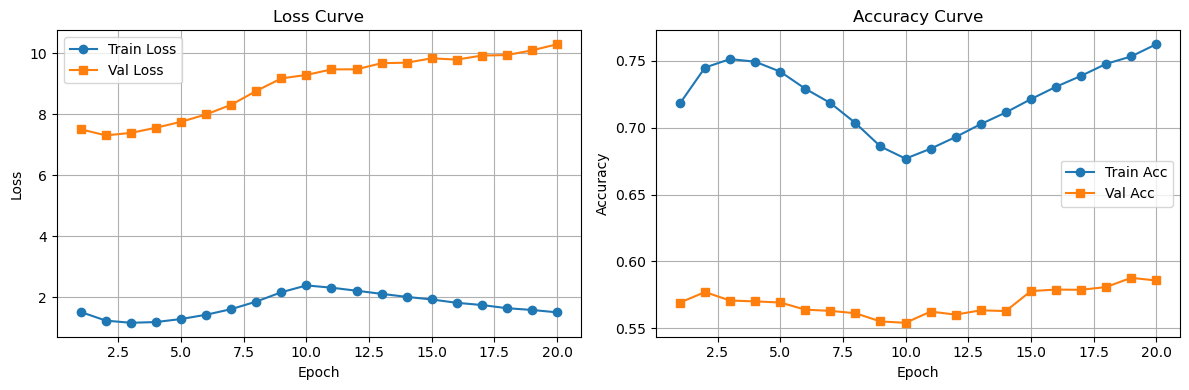

In [36]:
import matplotlib.pyplot as plt

epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'o-', label='Train Loss')
plt.plot(epochs, val_losses, 's-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, 'o-', label='Train Acc')
plt.plot(epochs, val_accs, 's-', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [38]:
# # 1. Learning Rate Scheduler 정의
# class LearningRateScheduler:
#     def __init__(self, d_model, warmup_steps=4000):
#         self.d_model = d_model
#         self.warmup_steps = warmup_steps

#     def __call__(self, step):
#         step = float(step)
#         arg1 = step ** -0.5
#         arg2 = step * (self.warmup_steps ** -1.5)
#         return (self.d_model ** -0.5) * min(arg1, arg2)

# # 2. 손실 함수 정의 (reshape 및 contiguous 적용으로 에러 해결)
# def loss_function(real, pred):
#     # real: [batch, seq], pred: [batch, seq, vocab]
#     mask = (real != 0).float()
    
#     # view 대신 reshape를 사용하거나 contiguous()를 호출하여 메모리 에러 방지
#     # 정답(real)과 예측(pred)의 차원을 맞추어 CrossEntropy 계산
#     loss_ = F.cross_entropy(pred.reshape(-1, pred.size(-1)), real.reshape(-1), reduction='none')
    
#     loss_ = loss_ * mask.reshape(-1)
#     return loss_.sum() / mask.sum()

# # 3. 최적화 도구 및 스케줄러 설정
# learning_rate = LearningRateScheduler(D_MODEL)
# optimizer = torch.optim.Adam(transformer.parameters(), 
#                              lr=learning_rate(1), 
#                              betas=(0.9, 0.98), 
#                              eps=1e-9)

# # 4. 모델 학습 루프
# from tqdm.auto import tqdm

# EPOCHS = 15 # 20

# for epoch in range(EPOCHS):
#     # --- [Train Phase] ---
#     transformer.train()
#     total_train_loss = 0
    
#     train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")
#     for src, tgt in train_bar:
#         # Node_12 방식: <s>... -> ...</s> 구조를 맞추기 위해 인덱싱
#         tgt_in = tgt[:, :-1]  # 마지막 토큰 제외 (입력용)
#         gold = tgt[:, 1:]     # 첫 토큰 제외 (정답용)
        
#         enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
        
#         optimizer.zero_grad()
        
#         # LR 업데이트
#         step = epoch * len(train_loader) + train_bar.n + 1
#         for param_group in optimizer.param_groups:
#             param_group['lr'] = learning_rate(step)
            
#         # Forward pass
#         predictions = transformer(src.to(device), tgt_in.to(device), 
#                                   enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device))
        
#         loss = loss_function(gold.to(device), predictions)
#         loss.backward()
#         optimizer.step()

#         total_train_loss += loss.item()
#         train_bar.set_postfix(loss=f"{loss.item():.4f}")

#     # --- [Validation Phase] ---
#     transformer.eval()
#     total_val_loss = 0
#     with torch.no_grad():
#         for src, tgt in val_loader:
#             tgt_in = tgt[:, :-1]
#             gold = tgt[:, 1:]
#             enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
            
#             predictions = transformer(src.to(device), tgt_in.to(device), 
#                                       enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device))
#             v_loss = loss_function(gold.to(device), predictions)
#             total_val_loss += v_loss.item()

#     avg_train_loss = total_train_loss / len(train_loader)
#     avg_val_loss = total_val_loss / len(val_loader)
    
#     print(f"▶ Epoch {epoch+1} 완료 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# print("\n✅ 학습 완료!")

Epoch 1 [Train]:   0%|          | 0/442 [00:00<?, ?it/s]

▶ Epoch 1 완료 | Train Loss: 1.0934 | Val Loss: 9.8431


Epoch 2 [Train]:   0%|          | 0/442 [00:00<?, ?it/s]

▶ Epoch 2 완료 | Train Loss: 0.9178 | Val Loss: 9.7013


Epoch 3 [Train]:   0%|          | 0/442 [00:00<?, ?it/s]

...

▶ Epoch 13 완료 | Train Loss: 1.7758 | Val Loss: 12.2294


Epoch 14 [Train]:   0%|          | 0/442 [00:00<?, ?it/s]

▶ Epoch 14 완료 | Train Loss: 1.7288 | Val Loss: 12.2277


Epoch 15 [Train]:   0%|          | 0/442 [00:00<?, ?it/s]

▶ Epoch 15 완료 | Train Loss: 1.6719 | Val Loss: 12.4328

✅ 학습 완료!


## Greedy Decoding

In [27]:
def chatbot_inference(input_sentence, tokenizer, model, device, max_len=50):
    model.eval()
    
    # 1. 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(input_sentence)
    tokens = mecab.morphs(sentence)
    
    # 2. 인코딩 (문장 앞뒤 <s>, </s> 포함)
    src_ids = tokenizer.encode_as_ids(" ".join(tokens))
    src_tensor = torch.LongTensor([src_ids]).to(device)
    
    # 3. 디코더 입력 초기화: 시작 토큰 <s> (ID: 1) 준비
    tgt_ids = [1]
    
    # 4. 최대 길이만큼 루프를 돌며 단어를 하나씩 생성 (Auto-regressive)
    for i in range(max_len):
        tgt_tensor = torch.LongTensor([tgt_ids]).to(device)
        
        # 마스크 생성
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
        
        with torch.no_grad():
            # 모델 예측
            predictions = model(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)
        
        # 마지막 타임스텝의 결과(로짓)에서 가장 확률이 높은 단어 선택
        # [batch, seq, vocab] 구조이므로 [:, -1:, :] 사용
        next_id = torch.argmax(predictions[:, -1:, :], dim=-1).item()
        
        # 생성된 단어를 다음 입력에 추가
        tgt_ids.append(next_id)
        
        # 끝 토큰 </s> (ID: 2)가 나오면 생성 중단
        if next_id == 2:
            break
            
    # 5. 특수 토큰(0~3) 제외하고 문장 복원
    result = tokenizer.decode_ids([i for i in tgt_ids if i > 3])
    return result

# --- [테스트 결과 확인] ---
print("--- [챗봇 대화 테스트] ---")
test_samples = [
    "반가워요",
    "오늘 날씨 어때?",
    "배고픈데 뭐 먹을까?",
    "졸려요",
    "고마워요"
]

for q in test_samples:
    answer = chatbot_inference(q, tokenizer, transformer, device)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print("-" * 30)

--- [챗봇 대화 테스트] ---
Q: 반가워요
A: 반갑 습니다 .
------------------------------
Q: 오늘 날씨 어때?
A: 오늘 도 고생 이 에요 .
------------------------------
Q: 배고픈데 뭐 먹을까?
A: 냉장고 파먹 기 하 는 게 좋 을 거 같 아요 .
------------------------------
Q: 졸려요
A: 다니 감사 합니다 .
------------------------------
Q: 고마워요
A: 공기 정답 죠 .
------------------------------


## Beam Search

In [28]:
import torch.nn.functional as F

def beam_search_decoder(input_sentence, tokenizer, model, device, beam_size=5, max_len=50):
    model.eval()
    
    # 1. 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(input_sentence)
    tokens = mecab.morphs(sentence)
    src_ids = tokenizer.encode_as_ids(" ".join(tokens))
    src_tensor = torch.LongTensor([src_ids]).to(device)

    # 2. 초기 상태 설정: (현재까지의 토큰 리스트, 누적 로그 확률)
    # 시작 토큰 <s> (ID: 1)로 시작
    beams = [([1], 0.0)]

    for _ in range(max_len):
        new_beams = []
        
        for tgt_ids, score in beams:
            # </s> 토큰이 이미 나왔다면 확정된 후보로 유지
            if tgt_ids[-1] == 2:
                new_beams.append((tgt_ids, score))
                continue

            tgt_tensor = torch.LongTensor([tgt_ids]).to(device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
            
            with torch.no_grad():
                # 모델 예측
                predictions = model(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)
            
            # 마지막 타임스텝의 확률 분포에 log 적용
            log_probs = F.log_softmax(predictions[:, -1:, :], dim=-1).squeeze()
            
            # 상위 beam_size개의 다음 단어 후보 추출
            top_v, top_i = torch.topk(log_probs, beam_size)

            for i in range(beam_size):
                next_id = top_i[i].item()
                next_score = score + top_v[i].item()
                new_beams.append((tgt_ids + [next_id], next_score))

        # 모든 후보 중 누적 점수가 높은 상위 beam_size개만 남김
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]

        # 모든 후보가 </s>를 포함하면 종료
        if all(tgt_ids[-1] == 2 for tgt_ids, _ in beams):
            break

    # 최상위 후보의 토큰 리스트 반환 (특수 토큰 제외)
    best_tgt_ids = beams[0][0]
    result = tokenizer.decode_ids([i for i in best_tgt_ids if i > 3])
    return result

# --- [Beam Search 테스트 결과 확인] ---
print("--- [챗봇 Beam Search 대화 테스트] ---")
test_samples = [
    "반가워요",
    "오늘 날씨 어때?",
    "배고픈데 뭐 먹을까?",
    "졸려요",
    "고마워요"
]

for q in test_samples:
    # beam_size를 5로 설정하여 더 신중하게 문장을 생성합니다.
    answer = beam_search_decoder(q, tokenizer, transformer, device, beam_size=5)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print("-" * 30)

--- [챗봇 Beam Search 대화 테스트] ---
Q: 반가워요
A: 반갑 습니다 .
------------------------------
Q: 오늘 날씨 어때?
A: 오늘 도 고생 이 에요 .
------------------------------
Q: 배고픈데 뭐 먹을까?
A: 맛있 게 드세요 .
------------------------------
Q: 졸려요
A: 다니 감사 합니다 .
------------------------------
Q: 고마워요
A: 공유 부탁 드립니다 .
------------------------------


→ 어떻게 내뱉을 것인가?를 정하는 알고리즘<br>
지금처럼 특정 문장에 갇혀 있을 때는 꺼내는 방법부터 바꿔서 모델이 가진 잠재력을 확인해보는 것이 효율적이다.<br>
이미 학습된 모델이 ‘답변을 골라내는 알고리즘’만 바꾸는 것이라 부품 교체하듯이 greeday search 코드 부분만 바꾸면 된다.


## 테스트 데이터셋 전체에 대한 BLEU Score 평가
Node_12.ipynb에서 사용한 nltk 라이브러리의 sentence_bleu를 활용하되, 챗봇 모델의 특성(자기 회귀적 생성)에 맞춰 테스트 데이터 전체의 평균 점수를 구하도록 구성

In [29]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
import numpy as np

def calculate_bleu(model, enc_test, dec_test, tokenizer, device, beam_size=5):
    """
    테스트 데이터셋 전체에 대해 BLEU Score의 평균을 계산합니다.
    """
    scores = []
    smoothie = SmoothingFunction().method1 # 점수가 0이 나오는 것을 방지하기 위한 보정
    
    print(f"✅ 총 {len(enc_test)}개의 테스트 데이터에 대해 BLEU 점수 계산 시작...")
    
    # 시간 관계상 상위 100개만 샘플링해서 평가하거나, 전체를 평가할 수 있습니다.
    # 여기서는 전체(len(enc_test))를 대상으로 합니다.
    for i in tqdm(range(len(enc_test))):
        # 1. 정답(Reference) 복원: 특수 토큰 제외
        reference = tokenizer.decode_ids([idx for idx in dec_test[i] if idx > 3]).split()
        
        # 2. 모델 생성(Candidate): Beam Search 활용
        # enc_test[i]는 이미 인코딩된 ID 리스트입니다.
        # beam_search_decoder 함수가 정제된 문장을 반환하므로 다시 split() 해줍니다.
        candidate_sentence = beam_search_decoder(tokenizer.decode_ids(enc_test[i]), 
                                                tokenizer, model, device, beam_size=beam_size)
        candidate = candidate_sentence.split()
        
        # 3. 단일 문장에 대한 BLEU 계산
        # 정답이 하나이므로 리스트로 감싸줍니다: [reference]
        score = sentence_bleu([reference], candidate, smoothing_function=smoothie)
        scores.append(score)
    
    avg_score = np.mean(scores)
    return avg_score

# --- [BLEU 평가 실행] ---
# 모델의 최종 성능을 확인합니다.
final_bleu = calculate_bleu(transformer, enc_test, dec_test, tokenizer, device, beam_size=5)

print(f"\n최종 결과")
print(f"테스트 데이터셋 평균 BLEU Score: {final_bleu * 100:.2f} 점")

✅ 총 1182개의 테스트 데이터에 대해 BLEU 점수 계산 시작...


  0%|          | 0/1182 [00:00<?, ?it/s]


최종 결과
테스트 데이터셋 평균 BLEU Score: 5.08 점
